In [1]:
# for colab
try:
    import google.colab

    !curl -LsSf https://astral.sh/uv/install.sh | sh
    !git clone https://github.com/stanfish06/micropattern.git /tmp/micropattern
    !cp -r /tmp/micropattern/. .
    !rm -rf /tmp/micropattern
    !pip install -e .
    import sys

    sys.path.insert(0, "/content/src")

    # remember to upload aws credentials
    !mkdir -p ~/.aws
    !cp /content/credentials ~/.aws
    !ls ~/.aws
except ImportError:
    raise RuntimeError(
        "make sure to connect to colab kernel or code above will wipe locally"
    )

downloading uv 0.10.2 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
Cloning into '/tmp/micropattern'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 63 (delta 29), reused 51 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 343.90 KiB | 1.92 MiB/s, done.
Resolving deltas: 100% (29/29), done.
Obtaining file:///content
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for micropattern (pyproject.toml) ... done
  Created wheel for micropattern: filename=micropattern-0.1.0-py3-none-any.whl size=1318 sha256=083f07a29993386c8aa028aca2743cd8b6155efec49804235d2c35d2b7c0a8c0
  Stored in directory: /tmp/pip-ephem-wheel-cache-q65g1ham/whe

In [2]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            47Gi       1.2Gi        30Gi       4.0Mi        15Gi        45Gi
Swap:             0B          0B          0B


In [3]:
import micropattern as mic
from pathlib import Path
import scprep
import scanpy as sc
import numpy as np

cwd = Path(".").resolve()
print(cwd)

/content


# Data download and prep

In [8]:
mic.io.fetch_minn(cwd)

100%|██████████| 1/1 [00:00<00:00, 13.07it/s]


100%|██████████| 1/1 [00:00<00:00,  6.68it/s]


100%|██████████| 1/1 [00:00<00:00,  1.58it/s]


100%|██████████| 1/1 [00:00<00:00, 16.83it/s]


100%|██████████| 1/1 [00:00<00:00, 16.50it/s]


...

100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


100%|██████████| 1/1 [00:00<00:00, 13.25it/s]


100%|██████████| 1/1 [00:00<00:00, 16.39it/s]


100%|██████████| 1/1 [00:01<00:00,  1.62s/it]


100%|██████████| 1/1 [00:00<00:00, 14.22it/s]


In [4]:
sample_list = []
for f in (cwd / "minn_data").glob("*.matrix.tsv.gz"):
    if f.is_file():
        sample_list.append(f.name.split(".")[0])
sample_list = list(set(sample_list))
sample_list.sort()
sample_list

['GSM5176718_gastruloid_0h_1',
 'GSM5176719_gastruloid_0h_2',
 'GSM5176720_gastruloid_12h_1',
 'GSM5176721_gastruloid_12h_2',
 'GSM5176722_gastruloid_24h_1',
 'GSM5176723_gastruloid_24h_2']

In [5]:
import pandas as pd
data_path = cwd / "minn_data"
data_list = {}
for s in sample_list:
    print(s)
    dat = scprep.io.load_mtx(
        data_path / f"{s}.matrix.tsv.gz",
        cell_axis="column",
        gene_names=str(data_path / f"{s}.genes.tsv.gz"),
        cell_names=str(data_path / f"{s}.barcodes.tsv.gz"),
        sparse=True,
    )
    dat.columns = dat.columns.str.replace("\t", " ")
    dat.columns = dat.columns.str.replace(" Gene Expression", "")
    dat.columns = pd.Index([g if len(g) == 1 else f"{g[1]} ({g[0]})" for g in dat.columns.str.split(" ")])
    data_list[s] = dat

GSM5176718_gastruloid_0h_1
GSM5176719_gastruloid_0h_2
GSM5176720_gastruloid_12h_1
GSM5176721_gastruloid_12h_2
GSM5176722_gastruloid_24h_1
GSM5176723_gastruloid_24h_2


# QC

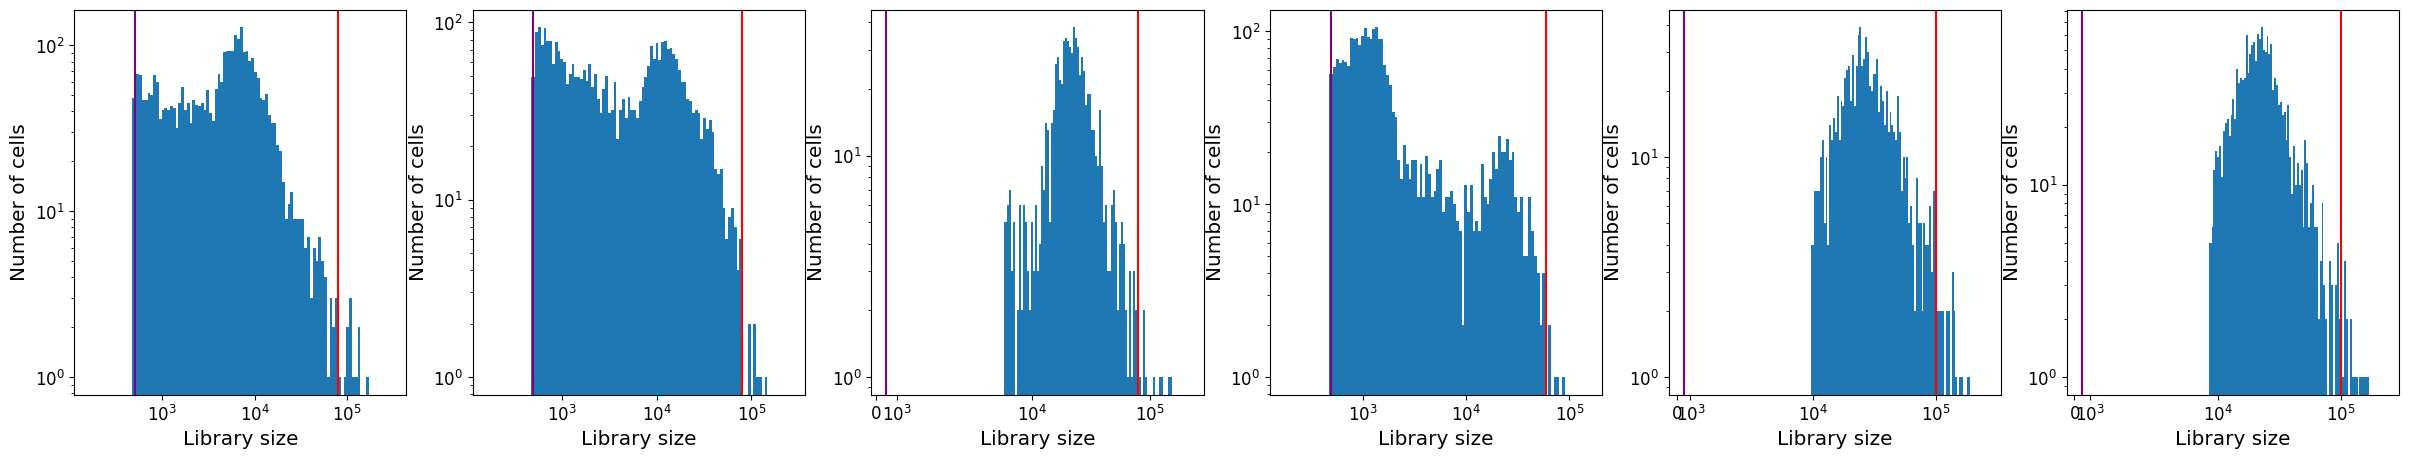

In [6]:
import matplotlib.pyplot as plt

_, axes = plt.subplots(1, len(data_list), figsize=(5 * len(data_list), 5))
thresholds = [
    (500, 8e4),
    (500, 8e4),
    (500, 8e4),
    (500, 6e4),
    (500, 1e5),
    (500, 1e5),
]
for (s, dat), (ax, th) in zip(data_list.items(), zip(axes, thresholds)):
    scprep.plot.plot_library_size(dat, ax=ax)
    ax.axvline(th[1], color='red')
    ax.axvline(th[0], color='purple')

before lib filtGSM5176718_gastruloid_0h_1: (3183, 32738)
after lib filt GSM5176718_gastruloid_0h_1: (3169, 32738)
after gene filt GSM5176718_gastruloid_0h_1: (3169, 16383)
before lib filtGSM5176719_gastruloid_0h_2: (3381, 32738)
after lib filt GSM5176719_gastruloid_0h_2: (3373, 32738)
after gene filt GSM5176719_gastruloid_0h_2: (3373, 17785)
before lib filtGSM5176720_gastruloid_12h_1: (784, 33694)
after lib filt GSM5176720_gastruloid_12h_1: (774, 33694)
after gene filt GSM5176720_gastruloid_12h_1: (774, 15087)
before lib filtGSM5176721_gastruloid_12h_2: (2492, 32738)
after lib filt GSM5176721_gastruloid_12h_2: (2484, 32738)
after gene filt GSM5176721_gastruloid_12h_2: (2484, 14852)
before lib filtGSM5176722_gastruloid_24h_1: (975, 33694)
after lib filt GSM5176722_gastruloid_24h_1: (951, 33694)
after gene filt GSM5176722_gastruloid_24h_1: (951, 15548)
before lib filtGSM5176723_gastruloid_24h_2: (1608, 33694)
after lib filt GSM5176723_gastruloid_24h_2: (1590, 33694)
after gene filt GSM51

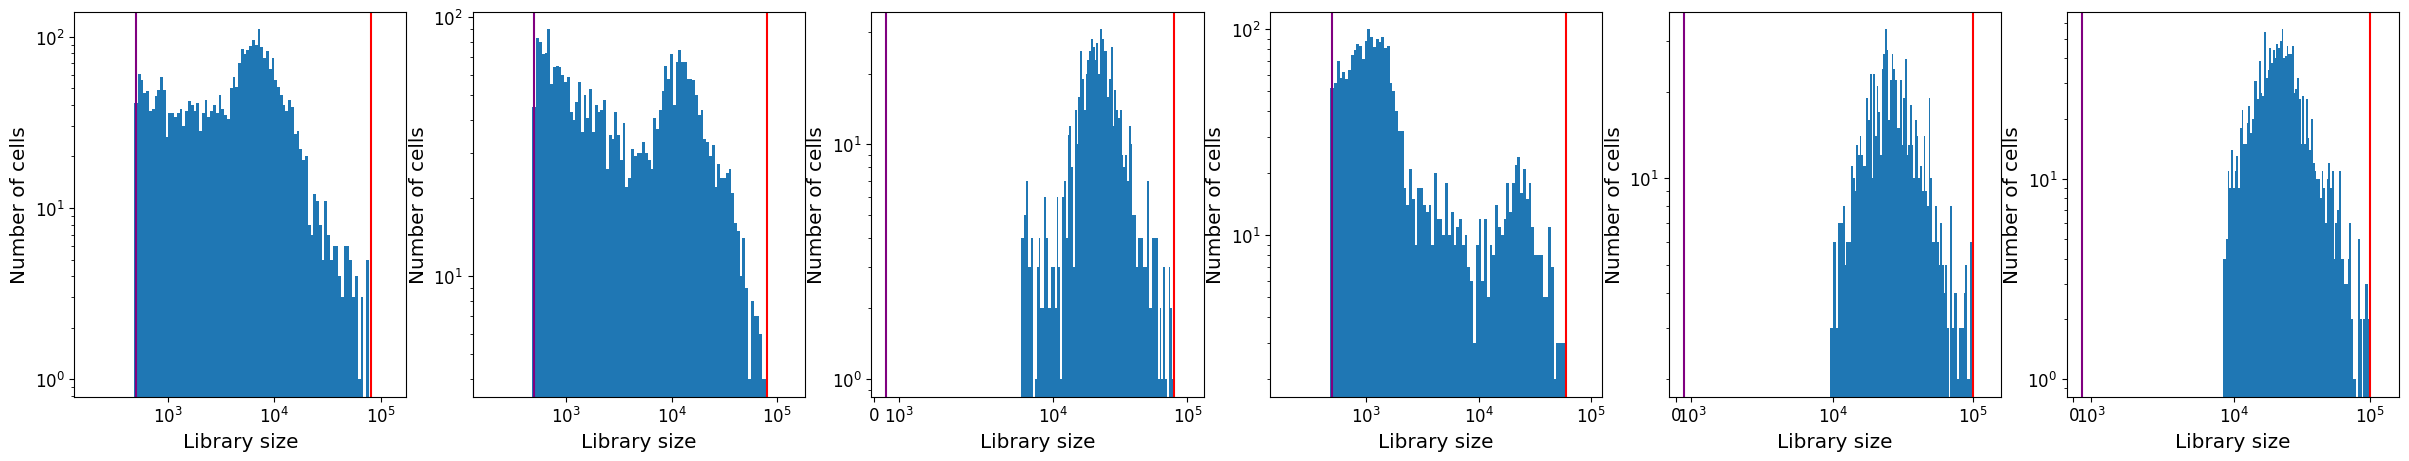

In [7]:
data_list_filt = {}
for (s, dat), th in zip(data_list.items(), thresholds):
    print(f"before lib filt{s}: {dat.shape}")
    dat = scprep.filter.filter_library_size(data=dat, cutoff=th)
    print(f"after lib filt {s}: {dat.shape}")
    dat = scprep.filter.remove_rare_genes(dat, cutoff=0, min_cells=5)
    print(f"after gene filt {s}: {dat.shape}")
    data_list_filt[s] = dat

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), (ax, th) in zip(data_list_filt.items(), zip(axes, thresholds)):
    scprep.plot.plot_library_size(dat, ax=ax)
    ax.axvline(th[1], color='red')
    ax.axvline(th[0], color='purple')

before mito filtGSM5176718_gastruloid_0h_1: (3169, 16383)
after mito filt GSM5176718_gastruloid_0h_1: (3041, 16383)
before mito filtGSM5176719_gastruloid_0h_2: (3373, 17785)
after mito filt GSM5176719_gastruloid_0h_2: (3238, 17785)
before mito filtGSM5176720_gastruloid_12h_1: (774, 15087)
after mito filt GSM5176720_gastruloid_12h_1: (743, 15087)
before mito filtGSM5176721_gastruloid_12h_2: (2484, 14852)
after mito filt GSM5176721_gastruloid_12h_2: (2384, 14852)
before mito filtGSM5176722_gastruloid_24h_1: (951, 15548)
after mito filt GSM5176722_gastruloid_24h_1: (912, 15548)
before mito filtGSM5176723_gastruloid_24h_2: (1590, 16147)
after mito filt GSM5176723_gastruloid_24h_2: (1526, 16147)


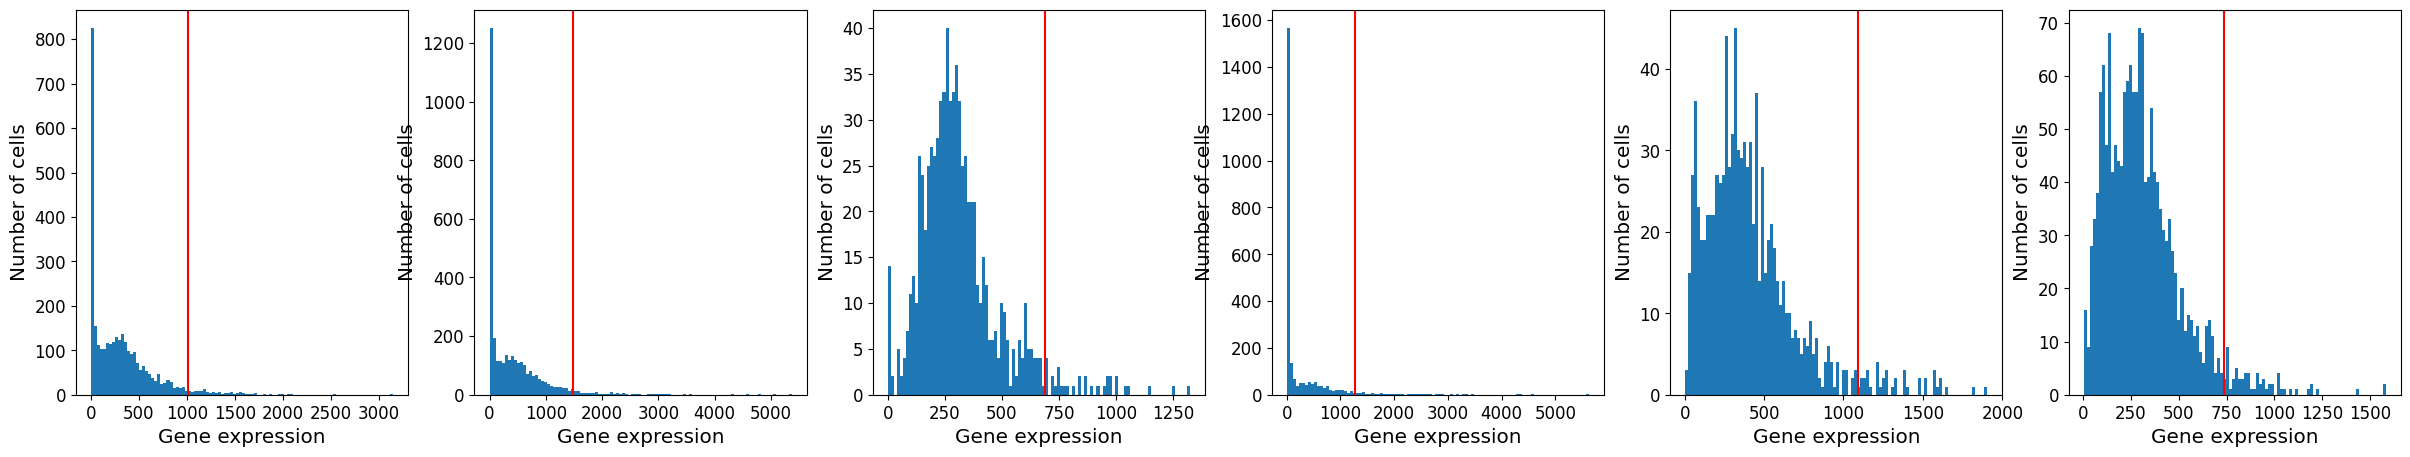

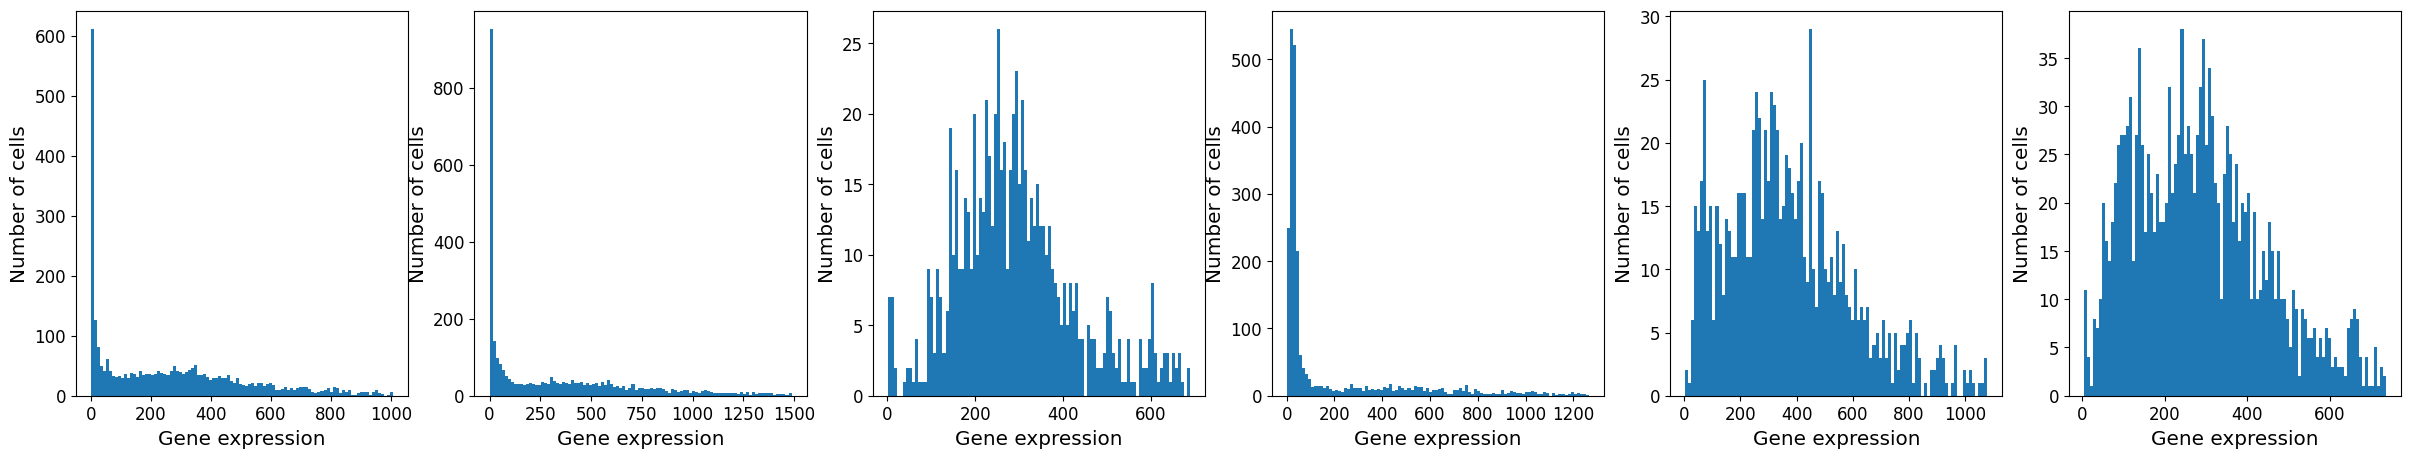

In [8]:
mt_genes = list(set.intersection(*[set(s) for s in [[g for g in dat.columns if g.startswith('MT-')] for dat in data_list_filt.values()]]))

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), ax in zip(data_list_filt.items(), axes):
    scprep.plot.plot_gene_set_expression(dat, genes=mt_genes, percentile=96, ax=ax)

for s, dat in data_list_filt.items():
    print(f"before mito filt{s}: {dat.shape}")
    dat = scprep.filter.filter_gene_set_expression(data=dat, genes=mt_genes, percentile=96, keep_cells="below")
    print(f"after mito filt {s}: {dat.shape}")
    data_list_filt[s] = dat
    
_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), ax in zip(data_list_filt.items(), axes):
    scprep.plot.plot_gene_set_expression(dat, genes=mt_genes, ax=ax)

In [9]:
# read paper's meta
import pandas as pd
from anndata import AnnData
adata_list = []
for s, dat in data_list_filt.items():
    adata = AnnData(dat)
    adata.obs["sample_labels"] = s
    adata.obs["barcode"] = adata.obs.index
    adata.obs["Time and replicate"] = s.split("_")[-2] + " Gastruloid Rep " + s.split("_")[-1]
    adata.obs["stage"] = s.split("_")[-2]
    rep_id = [s[-1] for s in adata.obs["sample_labels"].str.split("_")]
    adata.obs.index = pd.Index(adata.obs.index.str.cat(adata.obs["sample_labels"], sep='_'))
    adata_list.append(adata)
adata = sc.concat(adata_list)
# merge meta
meta = pd.read_csv(data_path / "GSE169074_gastruloid.all.time.metadata.csv.gz")
meta["barcode"] = [s[0] for s in meta["Cell ID"].str.split("_")]
meta = adata.obs.merge(meta, how="left", on=["barcode", "Time and replicate"])
meta.index = adata.obs.index
adata.obs = meta
mic.io.upload_minn_adata(adata, processing_stage="qc")

Saving AnnData to /tmp/tmpl9jn11vh/minn_gastruloid_0-24h_qc_20260211.h5ad
Uploading to s3://stan-sequencing-data/processed-active/Minn-micropattern-0-24h/minn_gastruloid_0-24h_qc_20260211.h5ad


100%|██████████| 1/1 [00:18<00:00, 18.39s/it]

Upload complete: s3://stan-sequencing-data/processed-active/Minn-micropattern-0-24h/minn_gastruloid_0-24h_qc_20260211.h5ad


In [11]:
adata

AnnData object with n_obs × n_vars = 11844 × 13035
    obs: 'sample_labels', 'barcode', 'Time and replicate', 'stage', 'Cell ID', 'Cell type'

# Integration

In [5]:
mic.io.fetch_minn(cwd, type="adata", stage="qc")

100%|██████████| 1/1 [03:38<00:00, 218.79s/it]


In [4]:
adata_qc = mic.io.MINN_ADATA_LIST["qc"]
data_path = cwd / "minn_data"

In [5]:
adata = sc.read_h5ad(data_path / adata_qc)

In [6]:
mic.utils.normalize_and_select_hvg(adata)

2026-02-12 21:47:36.371 | INFO     | micropattern.utils:normalize_and_select_hvg:57 - Copying X to counts layer before normalization
2026-02-12 21:47:36.513 | INFO     | micropattern.utils:normalize_and_select_hvg:61 - Normalizing to target sum 10000.0 and applying log1p transformation
2026-02-12 21:47:37.593 | INFO     | micropattern.utils:normalize_and_select_hvg:83 - Saving X to raw before computing HVG
2026-02-12 21:47:37.594 | INFO     | micropattern.utils:normalize_and_select_hvg:87 - Computing top 2000 highly variable genes (seurat_v3)


AnnData object with n_obs × n_vars = 11844 × 2000
    obs: 'sample_labels', 'barcode', 'Time and replicate', 'stage', 'Cell ID', 'Cell type'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg'
    layers: 'counts'